**Total Revenue Loss**

Revenue Loss = (room rate(ADR)* number of cancelled) + no-show bookings

In [ ]:
import pandas as pd

In [ ]:
# Load the train dataset
df = pd.read_csv('/content/drive/MyDrive/Data Science Life Cycle/Hotel_A_Train_Cleaned (1).csv')
df.columns

Index(['Reservation-id', 'Age', 'Expected_checkin', 'Expected_checkout',
       'Booking_date', 'Adults', 'Children', 'Babies', 'Reservation_Status',
       'Discount_Rate', 'Room_Rate', 'Lead_Time', 'Length_of_Stay',
       'Total_Guests', 'Checkin_Month', 'Is_Weekend', 'Gender_M',
       'Ethnicity_ASIAN AMERICAN', 'Ethnicity_CAUCASIAN', 'Ethnicity_LATINO',
       'Educational_Level_GRAD', 'Educational_Level_HIGH-SCHOOL',
       'Educational_Level_MID-SCHOOL', 'Income_50K -- 100K', 'Income_<25K',
       'Income_>100K', 'Country_region_NORTH', 'Country_region_SOUTH',
       'Country_region_WEST', 'Hotel_Type_CITY HOTEL', 'Hotel_Type_RESORT',
       'Meal_Type_FB', 'Meal_Type_HB', 'Visted_Previously_YES',
       'Previous_Cancellations_YES', 'Deposit_type_NON-REFUNDABLE',
       'Deposit_type_REFUNDABLE', 'Booking_channel_DIRECT',
       'Booking_channel_ONLINE', 'Required_Car_Parking_YES',
       'Use_Promotion_YES'],
      dtype='object')

In [ ]:
# Filter cancelled + no-show
cancelled_df = df[df['Reservation_Status'].isin([2, 3])]

# Calculate revenue loss
total_revenue_loss = cancelled_df['Room_Rate'].sum()

print("Total Revenue Loss: $", total_revenue_loss)

Total Revenue Loss: $ 1089430


**Revenue Loss by Age, Country, Region**

A) Revenue Loss by Age Group



In [ ]:
df['age_group'] = pd.cut(df['Age'],
                         bins=[18,30,45,70],
                         labels=['18-30','30-45','45-70'])

In [ ]:
# Add 'age_group' to cancelled_df if it's missing, by mapping from df
if 'age_group' not in cancelled_df.columns:
    # It's important to make a copy to avoid SettingWithCopyWarning
    # and ensure modifications are made on a standalone DataFrame.
    cancelled_df = cancelled_df.copy()
    cancelled_df['age_group'] = df['age_group'].loc[cancelled_df.index]

age_loss = cancelled_df.groupby('age_group', observed=False)['Room_Rate'].sum().reset_index()
print(age_loss)

  age_group  Room_Rate
0     18-30     251827
1     30-45     310167
2     45-70     512109


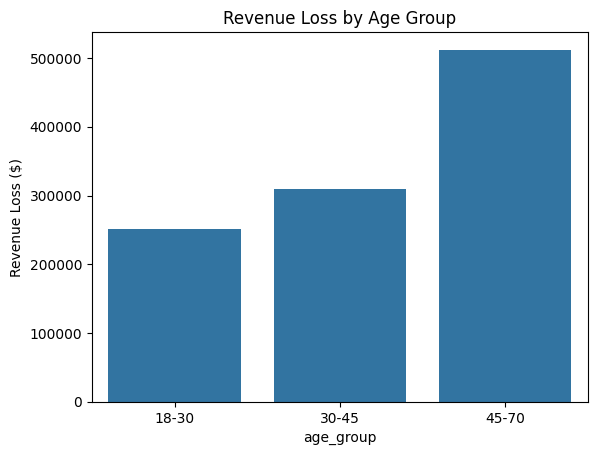

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=age_loss, x='age_group', y='Room_Rate')
plt.title("Revenue Loss by Age Group")
plt.ylabel("Revenue Loss ($)")
plt.show()

C) Revenue Loss by Day

In [ ]:
import pandas as pd
# Load the train dataset
df = pd.read_csv('/content/drive/MyDrive/Data Science Life Cycle/Hotel_A_Train_Cleaned (1).csv')

df['Day_Type'] = df['Is_Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

In [ ]:
loss_df = df[df['Reservation_Status'].isin([2,3])].copy()
loss_df['Day_Type'] = loss_df['Is_Weekend'].astype(int).map({
    1: 'Weekend',
    0: 'Weekday'
})

In [ ]:
day_pct = pd.crosstab(
    loss_df['Day_Type'],
    loss_df['Status_Label'],
    normalize='index'
) * 100
print(day_pct)

Status_Label   Canceled    No-Show
Day_Type                          
Weekday       66.084788  33.915212
Weekend       66.130820  33.869180


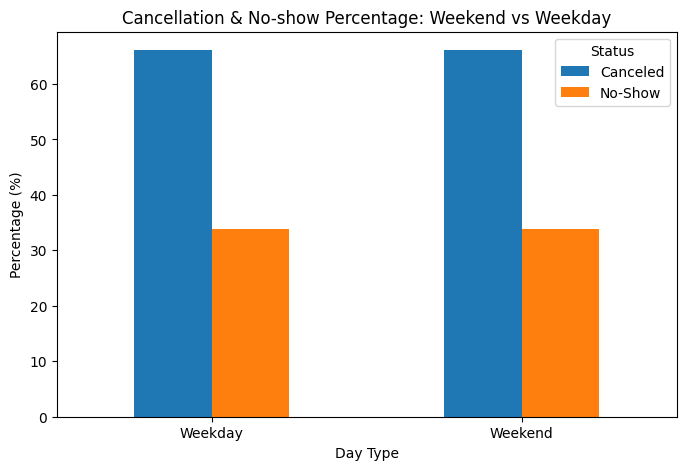

In [ ]:
import matplotlib.pyplot as plt

# Plot
day_pct[['Canceled', 'No-Show']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Cancellation & No-show Percentage: Weekend vs Weekday')
plt.ylabel('Percentage (%)')
plt.xlabel('Day Type')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

C) Revenue Loss by Region

In [ ]:
required_cols = ['Country_region_WEST', 'Country_region_NORTH', 'Country_region_SOUTH']

for col in required_cols:
    if col not in df.columns:
        df[col] = False

In [ ]:
import numpy as np

cancelled_df['Region'] = np.select(
    [
        cancelled_df['Country_region_WEST'],
        cancelled_df['Country_region_NORTH'],
        cancelled_df['Country_region_SOUTH']
    ],
    ['West', 'North', 'South'],
    default='Unknown'
)

In [ ]:
region_loss = cancelled_df.groupby('Region')['Room_Rate'].sum().reset_index()
print(region_loss)

    Region  Room_Rate
0    North     230680
1    South     429034
2  Unknown     215008
3     West     214708


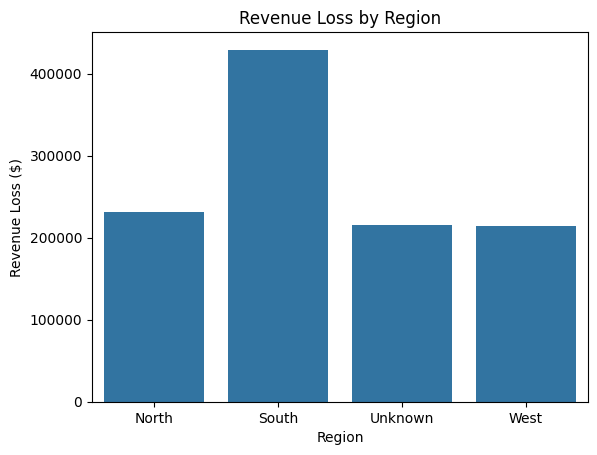

In [ ]:
sns.barplot(data=region_loss, x='Region', y='Room_Rate')
plt.title("Revenue Loss by Region")
plt.ylabel("Revenue Loss ($)")
plt.show()

In [ ]:
avg_loss = cancelled_df["Room_Rate"].mean()
print("Average Revenue Loss:", avg_loss)

Average Revenue Loss: 175.29042638777153


In [ ]:
df['is_cancelled'] = df['Reservation_Status'].isin([2])
weekend_cancel = df.groupby('Is_Weekend')['is_cancelled'].mean() * 100
print(weekend_cancel)

Is_Weekend
0    14.358899
1    17.837919
Name: is_cancelled, dtype: float64


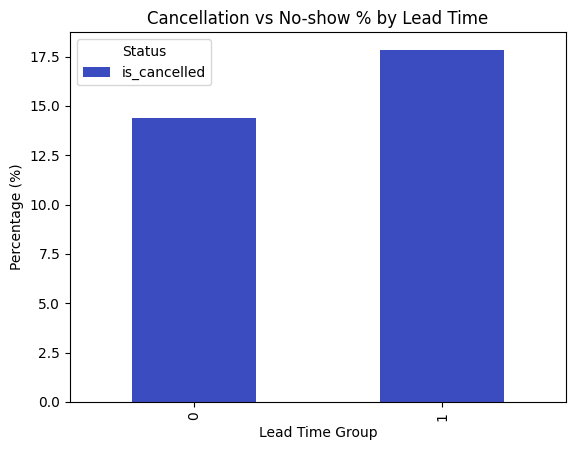

In [ ]:
weekend_cancel.plot(kind='bar',
                     stacked=True,
                     colormap='coolwarm')

plt.title('Cancellation vs No-show % by Lead Time')
plt.ylabel('Percentage (%)')
plt.xlabel('Lead Time Group')
plt.legend(title='Status')
plt.show()

In [ ]:
max_lead = df['Lead_Time'].max()
print("Highest Lead Time:", max_lead)

Highest Lead Time: 708


In [ ]:
df[df['Lead_Time'] == df['Lead_Time'].max()]

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Adults,Children,Babies,Reservation_Status,Discount_Rate,...,Visted_Previously_YES,Previous_Cancellations_YES,Deposit_type_NON-REFUNDABLE,Deposit_type_REFUNDABLE,Booking_channel_DIRECT,Booking_channel_ONLINE,Required_Car_Parking_YES,Use_Promotion_YES,age_group,is_cancelled
3921,81524080,65,2016-03-24,2016-03-25,2014-04-16,5,1,0,1,25,...,False,False,False,False,False,True,True,True,45-70,False


In [ ]:
df[df['Lead_Time_Group'] == 'Short']['Lead_Time'].mean()

KeyError: 'Lead_Time_Group'

In [ ]:
bins = [0, 14, 60, 708]
labels = ['Short', 'Medium', 'Long']

df['Lead_Time_Group'] = pd.cut(df['Lead_Time'],
                              bins=bins,
                              labels=labels,
                              include_lowest=True)

In [ ]:
df['Lead_Time_Group'].value_counts()

,count
Lead_Time_Group,
Long,18662
Medium,6234
Short,2093


In [ ]:
Lead_Time_cancel = df.groupby('Lead_Time_Group')['is_cancelled'].mean() * 100
print(Lead_Time_cancel)

Lead_Time_Group
Short     13.139035
Medium    13.506577
Long      16.027221
Name: is_cancelled, dtype: float64


/tmp/ipykernel_23119/1604503809.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Lead_Time_cancel = df.groupby('Lead_Time_Group')['is_cancelled'].mean() * 100


In [ ]:
promo_cancel = df.groupby('Use_Promotion_YES')['is_cancelled'].mean() * 100
print(promo_cancel)

Use_Promotion_YES
False    15.175909
True     15.235935
Name: is_cancelled, dtype: float64


In [ ]:
prev_cancel = df.groupby('Previous_Cancellations_YES')['is_cancelled'].mean() * 100
print(prev_cancel)

Previous_Cancellations_YES
False    15.334782
True     14.332354
Name: is_cancelled, dtype: float64


In [ ]:
channel_cancel = df.groupby('Booking_channel_ONLINE')['is_cancelled'].mean() * 100
print(channel_cancel)

Booking_channel_ONLINE
False    15.223523
True     15.219097
Name: is_cancelled, dtype: float64


In [ ]:
deposit_cancel = df.groupby('Deposit_type_NON-REFUNDABLE')['is_cancelled'].mean() * 100
print(deposit_cancel)

Deposit_type_NON-REFUNDABLE
False    15.236095
True     15.053763
Name: is_cancelled, dtype: float64


In [ ]:
cancelled_df = df[df['Reservation_Status'].isin([3])]

total_loss = cancelled_df['Room_Rate'].sum()
print("Total Revenue Loss:", total_loss)

Total Revenue Loss: 370625


In [ ]:
cancelled_df = df[df['Reservation_Status'].isin([2])]

total_loss = cancelled_df['Room_Rate'].sum()
print("Total Revenue Loss:", total_loss)

Total Revenue Loss: 718805


In [ ]:
loss_df = df[df['Reservation_Status'].isin([2,3])].copy()

In [ ]:
promo_loss = loss_df.groupby(['Is_Weekend', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

In [ ]:
df['Status_Label'] = df['Reservation_Status'].map({
    2: 'Canceled',
    3: 'No-Show'
})

In [ ]:
df['Day_Type'] = df['Is_Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

In [ ]:
loss_df['Status_Label'] = df['Status_Label'].loc[loss_df.index]
lead_pct = pd.crosstab(
    loss_df['Lead_Time_Group'],
    loss_df['Status_Label'],
    normalize='index'
) * 100

In [ ]:
loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

/tmp/ipykernel_23119/3909338190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \


,Lead_Time_Group,Reservation_Status,Room_Rate
0,Short,2,47973
1,Short,3,23067
2,Medium,2,148063
3,Medium,3,76627
4,Long,2,522769
5,Long,3,270931


In [ ]:
loss_df.groupby(['Previous_Cancellations_YES', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Previous_Cancellations_YES,Reservation_Status,Room_Rate
0,False,2,642372
1,False,3,329033
2,True,2,76433
3,True,3,41592


In [ ]:
loss_df.groupby(['Booking_channel_ONLINE', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Booking_channel_ONLINE,Reservation_Status,Room_Rate
0,False,2,309007
1,False,3,159921
2,True,2,409798
3,True,3,210704


In [ ]:
loss_df.groupby(['Deposit_type_NON-REFUNDABLE', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Deposit_type_NON-REFUNDABLE,Reservation_Status,Room_Rate
0,False,2,660636
1,False,3,339176
2,True,2,58169
3,True,3,31449


In [ ]:
high_risk_avg = cancelled_df['Room_Rate'].mean()

deposit = high_risk_avg * 0.3   # 30%
print(deposit)

52.493062317429406


In [ ]:
df['Risk_Prob'] = df['Room_Rate'] / df['Room_Rate'].max() # Example: define Risk_Prob based on Room_Rate
df['Risk_Level'] = pd.cut(df['Risk_Prob'],
                              bins=[0, 0.33, 0.66, 1],
                              labels=['Low', 'Medium', 'High'])